# IPL Ball-by-Ball — Exploratory Data Analysis

295,557 deliveries across 1,243 matches, IPL 2008–2026, from the Cricsheet archive.

**Questions:**
1. Is the parsed data internally consistent?
2. Do the scoring conventions actually change the answers?
3. How has scoring evolved, and is the 2023 Impact Player rule visible?
4. How different are the three phases of an innings?
5. How should a batter's weakness be measured?
6. Does winning the toss matter?

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 130)
pd.set_option('display.max_columns', 30)

deliveries = pd.read_csv(ROOT / 'data' / 'processed' / 'deliveries.csv',
                         dtype={'season': str})
matches = pd.read_csv(ROOT / 'data' / 'processed' / 'matches.csv',
                      dtype={'season': str})

PHASE_ORDER = ['Powerplay', 'Middle', 'Death']

print(f'{len(deliveries):,} deliveries')
print(f'{len(matches):,} matches')
print(f"Seasons {matches['season_year'].min()}-{matches['season_year'].max()}")

295,732 deliveries
1,243 matches
Seasons 2008-2026


In [2]:
deliveries.head()

,match_id,season,date,venue,innings,is_super_over,batting_team,bowling_team,over,ball_in_over,phase,batter,bowler,non_striker,runs_batter,runs_extras,runs_total,wides,noballs,byes,legbyes,is_legal_delivery,is_four,is_six,is_dot,is_wicket,dismissal_kind,player_out,is_bowler_wicket,season_year
0,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,False,Sunrisers Hyderabad,Royal Challengers Bengaluru,0,1,Powerplay,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,True,False,False,True,False,NaN,NaN,False,2017
1,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,False,Sunrisers Hyderabad,Royal Challengers Bengaluru,0,2,Powerplay,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,True,False,False,True,False,NaN,NaN,False,2017
2,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,False,Sunrisers Hyderabad,Royal Challengers Bengaluru,0,3,Powerplay,DA Warner,TS Mills,S Dhawan,4,0,4,0,0,0,0,True,True,False,False,False,NaN,NaN,False,2017
3,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,False,Sunrisers Hyderabad,Royal Challengers Bengaluru,0,4,Powerplay,DA Warner,TS Mills,S Dhawan,0,0,0,0,0,0,0,True,False,False,True,False,NaN,NaN,False,2017
4,1082591,2017,2017-04-05,"Rajiv Gandhi International Stadium, Uppal",1,False,Sunrisers Hyderabad,Royal Challengers Bengaluru,0,5,Powerplay,DA Warner,TS Mills,S Dhawan,0,2,2,2,0,0,0,False,False,False,False,False,NaN,NaN,False,2017


## 2. Integrity checks

Before any analysis, confirm the parse is internally consistent. If runs do not add up at the ball level, nothing downstream can be trusted.

In [3]:
checks = {
    'runs_total = batter + extras':
        (deliveries.runs_batter + deliveries.runs_extras
         == deliveries.runs_total).all(),
    'batter runs in 0-6':
        deliveries.runs_batter.between(0, 6).all(),
    'every wicket names a player':
        deliveries[deliveries.is_wicket].player_out.notna().all(),
    'bowler wickets subset of all wickets':
        not (deliveries.is_bowler_wicket & ~deliveries.is_wicket).any(),
    'no season before 2008':
        (matches.season_year >= 2008).all(),
    'overs within 0-19 (non super-over)':
        deliveries[~deliveries.is_super_over].over.between(0, 19).all(),
}
for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")

PASS  runs_total = batter + extras
PASS  batter runs in 0-6
PASS  every wicket names a player
PASS  bowler wickets subset of all wickets
PASS  no season before 2008
PASS  overs within 0-19 (non super-over)


In [4]:
print('Dismissal kinds and how often each occurs:')
print(deliveries.dismissal_kind.value_counts().to_string())
print()
credited = deliveries.is_bowler_wicket.sum()
total = deliveries.is_wicket.sum()
print(f'Total wickets      : {total:,}')
print(f'Credited to bowler : {credited:,}')
print(f'Not credited       : {total - credited:,} '
      f'({(total - credited) / total * 100:.1f}%)')

Dismissal kinds and how often each occurs:
dismissal_kind
caught                   9321
bowled                   2460
run out                  1194
lbw                       883
caught and bowled         410
stumped                   388
hit wicket                 20
retired hurt               19
retired out                 6
obstructing the field       4

Total wickets      : 14,705
Credited to bowler : 13,482
Not credited       : 1,223 (8.3%)


Just over 8% of dismissals are run-outs and retirements, which are **not** the bowler's wicket. Treating every dismissal as a bowler wicket would inflate strike-bowler records by roughly that much.

## 3. Do the scoring conventions actually matter?

It is easy to state conventions and assume they are a formality. They are not. Below, the same bowlers are ranked twice — once with the correct treatment, once with the naive one that counts every ball and charges every run.

In [5]:
play = deliveries[~deliveries.is_super_over].copy()
play['runs_conceded'] = play.runs_total - play.byes - play.legbyes

death = play[play.phase == 'Death']

# Correct: legal balls only, byes and leg-byes excluded.
legal = death[death.is_legal_delivery]
correct = legal.groupby('bowler').agg(
    balls=('is_legal_delivery', 'sum'),
    runs=('runs_conceded', 'sum'),
)
correct['economy'] = correct.runs / correct.balls * 6

# Naive: every delivery counted, every run charged.
naive = death.groupby('bowler').agg(
    balls=('runs_total', 'size'),
    runs=('runs_total', 'sum'),
)
naive['economy'] = naive.runs / naive.balls * 6

compare = correct[['balls', 'economy']].join(
    naive[['economy']], rsuffix='_naive'
)
compare = compare[compare.balls >= 300].copy()
compare['difference'] = (compare.economy - compare.economy_naive).round(2)
compare = compare.sort_values('economy').head(12).round(2)
compare

,balls,economy,economy_naive,difference
bowler,,,,
SP Narine,1105,7.08,7.26,-0.18
SL Malinga,1117,7.47,7.80,-0.33
R Ashwin,601,7.84,7.99,-0.16
JJ Bumrah,1423,7.86,8.07,-0.20
DW Steyn,634,7.95,8.11,-0.16
B Lee,311,8.22,8.51,-0.29
M Pathirana,402,8.34,8.61,-0.26
CH Morris,646,8.36,8.56,-0.20
AR Patel,382,8.40,8.58,-0.17


In [6]:
print(f'Mean absolute difference in economy: '
      f'{compare.difference.abs().mean():.3f} runs per over')
print()
print('Rank changes between the two methods:')
rank_correct = correct[correct.balls >= 300].economy.rank()
rank_naive = naive.loc[rank_correct.index].economy.rank()
moved = (rank_correct - rank_naive).abs()
print(f'  bowlers whose rank moves at all : {(moved > 0).sum()} '
      f'of {len(moved)}')
print(f'  largest rank move               : {moved.max():.0f} places')

Mean absolute difference in economy: 0.198 runs per over

Rank changes between the two methods:
  bowlers whose rank moves at all : 51 of 68
  largest rank move               : 8 places


The conventions are not cosmetic. They move economy rates by a meaningful fraction of a run per over and reshuffle the ranking. Any cricket analysis that does not state its conventions is not reproducible, because a reader cannot tell which numbers they are looking at.

## 4. Scoring across nineteen seasons

In [7]:
trends = play.groupby('season_year').agg(
    matches=('match_id', 'nunique'),
    runs=('runs_total', 'sum'),
    balls=('is_legal_delivery', 'sum'),
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dots=('is_dot', 'sum'),
)
trends['run_rate'] = (trends.runs / trends.balls * 6).round(2)
trends['boundary_pct'] = (
    (trends.fours + trends.sixes) / trends.balls * 100
).round(1)
trends['dot_pct'] = (trends.dots / trends.balls * 100).round(1)
trends['sixes_per_match'] = (trends.sixes / trends.matches).round(1)
trends[['matches', 'run_rate', 'boundary_pct', 'dot_pct', 'sixes_per_match']]

,matches,run_rate,boundary_pct,dot_pct,sixes_per_match
season_year,,,,,
2008,58,8.31,18.0,38.0,10.7
2009,57,7.48,13.9,39.1,8.9
2010,60,8.13,16.5,35.8,9.8
2011,73,7.73,15.6,38.2,8.8
2012,74,7.83,15.4,36.3,9.9
2013,76,7.68,15.5,38.4,8.9
2014,60,8.20,16.5,36.3,11.9
2015,59,8.37,17.5,36.3,11.7
2016,60,8.31,16.7,34.1,10.6


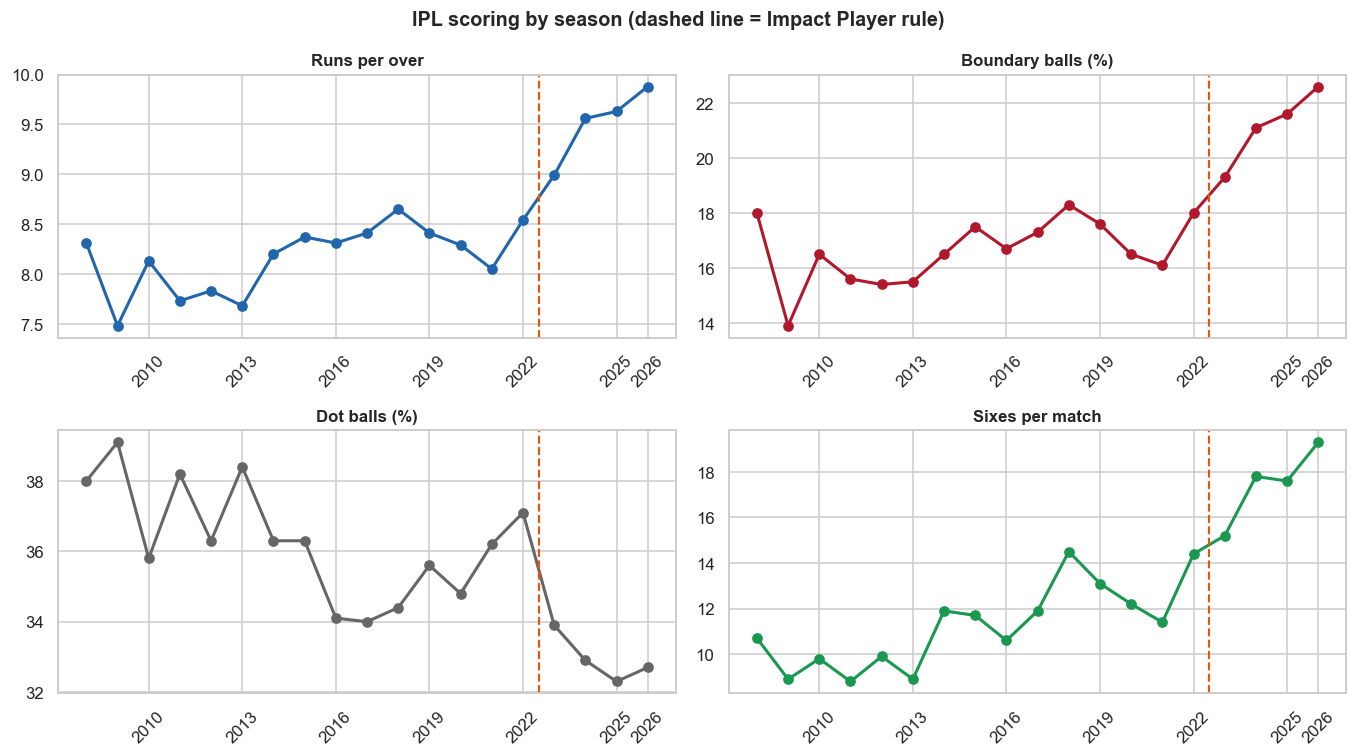

Run rate, five seasons before 2023 : 8.39
Run rate, 2023 onwards             : 9.52
Change                             : +1.13 runs/over


In [8]:
IMPACT = 2023
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7))
panels = [('run_rate', 'Runs per over', '#2166ac'),
          ('boundary_pct', 'Boundary balls (%)', '#b2182b'),
          ('dot_pct', 'Dot balls (%)', '#666666'),
          ('sixes_per_match', 'Sixes per match', '#1a9850')]
ticks = [y for y in trends.index if y % 3 == 0 or y == trends.index.max()]
for ax, (col, title, colour) in zip(axes.flat, panels):
    ax.plot(trends.index, trends[col], marker='o', lw=2, color=colour)
    ax.axvline(IMPACT - 0.5, color='#e6550d', ls='--', lw=1.4)
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(y) for y in ticks], rotation=45)
fig.suptitle('IPL scoring by season (dashed line = Impact Player rule)',
             fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

pre = trends.loc[trends.index < IMPACT, 'run_rate'].tail(5).mean()
post = trends.loc[trends.index >= IMPACT, 'run_rate'].mean()
print(f'Run rate, five seasons before 2023 : {pre:.2f}')
print(f'Run rate, 2023 onwards             : {post:.2f}')
print(f'Change                             : {post - pre:+.2f} runs/over')

All four series turn at the same point. The Impact Player rule lets a side substitute a player mid-match, which in practice means batting deeper without the risk that used to carry.

**But four series turning together is exactly what you would expect from any cause that makes batting easier** — flatter pitches, better bats, shorter boundaries. The rule change is the most visible thing that happened in 2023, not the only thing. This is an association in a time series with n=4 post-rule seasons, and it should be described as one.

## 5. The three phases

In [9]:
phases = play.groupby('phase').agg(
    balls=('is_legal_delivery', 'sum'),
    runs=('runs_total', 'sum'),
    wickets=('is_wicket', 'sum'),
    fours=('is_four', 'sum'),
    sixes=('is_six', 'sum'),
    dots=('is_dot', 'sum'),
).reindex(PHASE_ORDER)
phases['run_rate'] = (phases.runs / phases.balls * 6).round(2)
phases['balls_per_wicket'] = (phases.balls / phases.wickets).round(1)
phases['boundary_pct'] = (
    (phases.fours + phases.sixes) / phases.balls * 100
).round(1)
phases['dot_pct'] = (phases.dots / phases.balls * 100).round(1)
phases[['balls', 'run_rate', 'boundary_pct', 'dot_pct', 'balls_per_wicket']]

,balls,run_rate,boundary_pct,dot_pct,balls_per_wicket
phase,,,,,
Powerplay,89153,8.09,20.4,46.3,24.9
Middle,131526,7.95,14.3,31.8,23.0
Death,63786,10.06,20.8,28.4,11.8


The death overs score far faster and cost wickets far more often. This is the reason every player comparison in this project is made **within** a phase — a strike rate of 140 means something completely different in the powerplay than at the death.

## 6. Measuring a batter's weakness

The tempting approach is to compare a batter's strike rate across their own phases and call the lowest one their weakness. That is guaranteed to be wrong: **everyone** scores slowest in the powerplay and fastest at the death, so this method would label almost every batter in the league a powerplay weakness.

The comparison has to be against what *other batters* manage in the same phase. Both are computed below.

In [10]:
faced = play[play.wides == 0]  # a wide is not a ball faced
g = faced.groupby(['batter', 'phase'])
b = pd.DataFrame({
    'balls': g.size(),
    'runs': g.runs_batter.sum(),
    'dismissals': g.is_wicket.sum(),
    'dots': g.is_dot.sum(),
}).reset_index()
b = b[b.balls >= 200].copy()
b['strike_rate'] = (b.runs / b.balls * 100).round(1)
b['dot_pct'] = (b.dots / b.balls * 100).round(1)
b['balls_per_dismissal'] = (
    b.balls / b.dismissals.replace(0, np.nan)
).round(1)

league = b.groupby('phase').apply(
    lambda x: x.runs.sum() / x.balls.sum() * 100, include_groups=False
)
b['league_sr'] = b.phase.map(league).round(1)
b['vs_league'] = (b.strike_rate - b.league_sr).round(1)

print('League strike rate by phase:')
print(league.round(1).to_string())
print(f'\n{b.batter.nunique()} batters clear 200 balls in at least one phase')

League strike rate by phase:
phase
Death        168.3
Middle       128.5
Powerplay    129.0

174 batters clear 200 balls in at least one phase


In [11]:
complete = b.groupby('batter').phase.nunique()
complete = complete[complete == 3].index
full = b[b.batter.isin(complete)]

naive_weakest = full.loc[full.groupby('batter').strike_rate.idxmin()]
proper_weakest = full.loc[full.groupby('batter').vs_league.idxmin()]

print('Naive method - lowest raw strike rate:')
print(naive_weakest.phase.value_counts().to_string())
print()
print('Proper method - furthest below the league in that phase:')
print(proper_weakest.phase.value_counts().to_string())

Naive method - lowest raw strike rate:
phase
Powerplay    25
Middle       11

Proper method - furthest below the league in that phase:
phase
Powerplay    18
Death        10
Middle        8


The naive method assigns nearly every batter the same 'weakness', because it is measuring the phase effect rather than the player. The league-relative method spreads them across all three phases, which is what a genuine per-player signal looks like.

In [12]:
proper_weakest.sort_values('vs_league')[
    ['batter', 'phase', 'balls', 'strike_rate', 'league_sr',
     'vs_league', 'dot_pct', 'balls_per_dismissal']
].head(15)

,batter,phase,balls,strike_rate,league_sr,vs_league,dot_pct,balls_per_dismissal
1232,S Badrinath,Powerplay,237,76.8,129.0,-52.2,61.2,39.5
863,MK Tiwary,Powerplay,230,97.4,129.0,-31.6,51.3,23.0
613,JP Duminy,Powerplay,239,98.3,129.0,-30.7,54.0,39.8
663,KD Karthik,Powerplay,402,98.5,129.0,-30.5,52.2,40.2
587,JH Kallis,Middle,1012,98.5,128.5,-30.0,31.6,32.6
702,KS Williamson,Powerplay,477,100.4,129.0,-28.6,50.3,34.1
972,NV Ojha,Death,294,139.8,168.3,-28.5,36.4,10.9
150,AT Rayudu,Powerplay,732,106.1,129.0,-22.9,50.4,31.8
905,Mandeep Singh,Death,274,149.6,168.3,-18.7,22.3,11.0
1569,WP Saha,Middle,900,109.8,128.5,-18.7,30.4,23.7


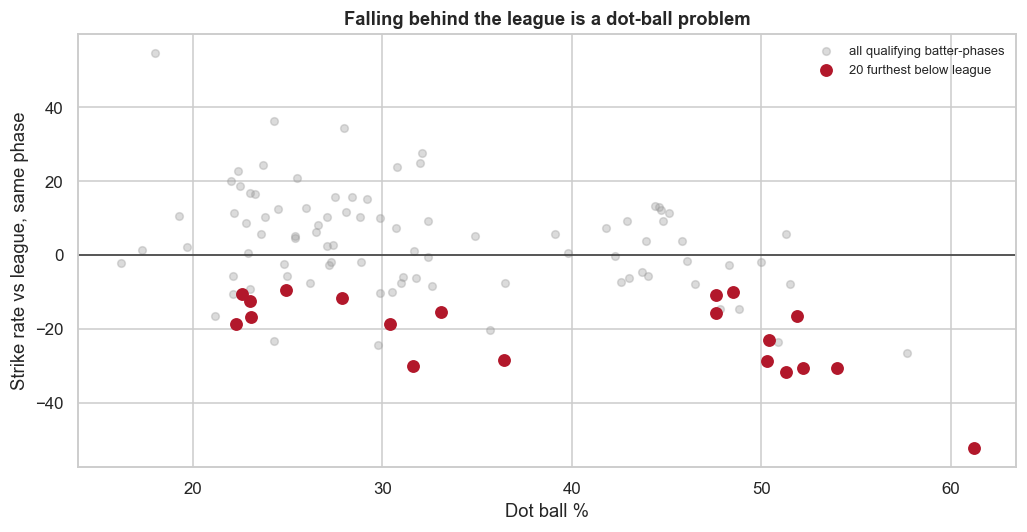

Correlation, dot% vs league-relative SR       : -0.443
Correlation, survival vs league-relative SR   : -0.334


In [13]:
worst = proper_weakest.nsmallest(20, 'vs_league')
rest = full[~full.index.isin(worst.index)]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.scatter(rest.dot_pct, rest.vs_league, s=25, alpha=0.35,
           color='#999', label='all qualifying batter-phases')
ax.scatter(worst.dot_pct, worst.vs_league, s=55, color='#b2182b',
           label='20 furthest below league')
ax.axhline(0, color='#333', lw=1)
ax.set_xlabel('Dot ball %')
ax.set_ylabel('Strike rate vs league, same phase')
ax.set_title('Falling behind the league is a dot-ball problem',
             weight='bold')
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

corr = full[['dot_pct', 'vs_league']].corr().iloc[0, 1]
corr_dismissal = full[['balls_per_dismissal', 'vs_league']].corr().iloc[0, 1]
print(f'Correlation, dot% vs league-relative SR       : {corr:.3f}')
print(f'Correlation, survival vs league-relative SR   : {corr_dismissal:.3f}')

Strike rotation has the stronger relationship: dot percentage correlates at −0.44 with falling behind the league, against −0.33 for survival.

That is a real difference but not a decisive one — dot balls explain roughly 20% of the variance and survival about 11%, so **both matter**. The honest reading is that batters who fall behind tend to be playing more dot balls *and* getting out somewhat more, with the dot-ball effect the larger of the two. Claiming the weakness is purely a rotation problem would overstate a 0.11 gap in correlation.

## 7. Does winning the toss matter?

In [14]:
from scipy import stats

decided = matches[matches.winner.notna() & matches.toss_winner.notna()].copy()
decided['toss_won'] = decided.toss_winner == decided.winner

n, wins = len(decided), decided.toss_won.sum()
p = stats.binomtest(int(wins), n, 0.5).pvalue
print(f'Decided matches      : {n:,}')
print(f'Toss winner also won : {wins:,} ({wins / n * 100:.1f}%)')
print(f'Binomial test p      : {p:.3f}')
print()
print('-> Winning the toss on its own is close to a coin flip.')

Decided matches      : 1,218
Toss winner also won : 628 (51.6%)
Binomial test p      : 0.289

-> Winning the toss on its own is close to a coin flip.


In [15]:
field = decided[decided.toss_decision == 'field']
bat = decided[decided.toss_decision == 'bat']

table = [[int(field.toss_won.sum()), int((~field.toss_won).sum())],
         [int(bat.toss_won.sum()), int((~bat.toss_won).sum())]]
chi2, p_dec, _, _ = stats.chi2_contingency(table)

print(f'Chose to field : {len(field):>5,} matches, '
      f'won {field.toss_won.mean() * 100:.1f}%')
print(f'Chose to bat   : {len(bat):>5,} matches, '
      f'won {bat.toss_won.mean() * 100:.1f}%')
print(f'\nGap            : '
      f'{(field.toss_won.mean() - bat.toss_won.mean()) * 100:.1f} points')
print(f'Chi-square p   : {p_dec:.4f}')
print()
print(f'Captains chose to field in {len(field) / n * 100:.0f}% of matches.')

Chose to field :   810 matches, won 54.7%
Chose to bat   :   408 matches, won 45.3%

Gap            : 9.3 points
Chi-square p   : 0.0025

Captains chose to field in 67% of matches.


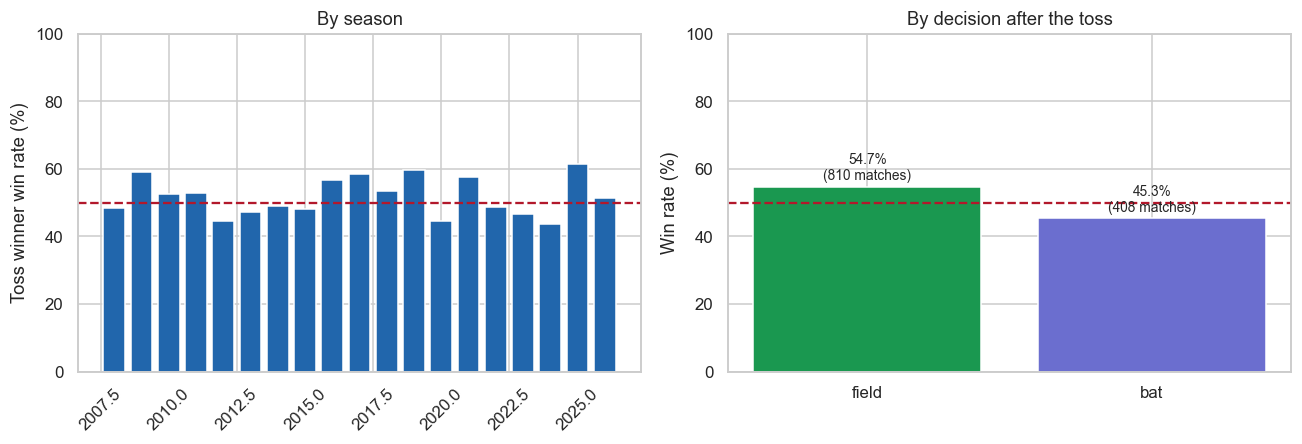

In [16]:
by_season = (decided.groupby('season_year').toss_won.mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(by_season.index, by_season.values, color='#2166ac')
axes[0].axhline(50, color='#b2182b', ls='--', lw=1.5)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Toss winner win rate (%)')
axes[0].set_title('By season')
axes[0].tick_params(axis='x', rotation=45)

rates = [field.toss_won.mean() * 100, bat.toss_won.mean() * 100]
axes[1].bar(['field', 'bat'], rates, color=['#1a9850', '#6b6ecf'])
axes[1].axhline(50, color='#b2182b', ls='--', lw=1.5)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Win rate (%)')
axes[1].set_title('By decision after the toss')
for i, (r, cnt) in enumerate(zip(rates, [len(field), len(bat)])):
    axes[1].text(i, r + 2, f'{r:.1f}%\n({cnt} matches)',
                 ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**The toss is not the interesting variable. The innings order is.**

Winning the toss is a coin flip. Choosing to field is worth about nine percentage points, and that gap is significant. The standard explanation is evening dew: it makes the ball harder to grip in the second innings, so chasing is easier.

**This is not a causal estimate.** Captains do not choose at random — they field when conditions favour chasing and bat when they do not. Part of the nine-point gap is the conditions that prompted the decision rather than the decision itself. A cleaner design would need venue and start-time controls, and ideally a source of variation in the decision that is unrelated to conditions.

## 8. What the exploration establishes

1. **The parse is internally consistent** — runs reconcile at ball level, wickets are attributed correctly, seasons land in the right years.
2. **Scoring conventions change the answers**, not just the presentation. They move death economy rates and reshuffle the ranking, so they have to be stated.
3. **Scoring rose sharply from 2023**, coincident with the Impact Player rule — an association across four post-rule seasons, not a causal finding.
4. **The phases are different games**, so all player comparisons are made within a phase.
5. **Batter weakness must be measured league-relative.** The naive within-player method measures the phase effect and labels nearly everyone the same way.
6. **The toss is a coin flip; the decision is not** — and even that gap is confounded by the conditions captains are responding to.

The recurring theme, as in the other projects in this portfolio, is that the comparison design decides the answer.